## **M3 Vision — Week 1 Setup**

### **Pipeline: PyBullet Scene to Feature Vector to RL Policy**

**Goal (Week 2 Deliverable):**
 fixed-size observation tensor from each rendered frame so the RL team can plug it directly into their PPO policy.

### **Pipeline Steps I used**

1. **Render from PyBullet**

   * RGB image: `(224, 224, 3)`
   * Depth map: `(224, 224)`
   * Segmentation mask: `(224, 224)`

2. **Extract Bounding Boxes**

   * From segmentation mask
   * Up to **5 objects**
   * Each represented as:

     ```
     [x1, y1, x2, y2, depth]
     ```
   * Output shape: `(5 × 5 = 25)`

3. **Visual Feature Extraction (FPN Backbone)**

   *  **Faster R-CNN backbone (FPN)**
   * Extract global visual embedding
   * Output shape: `(256,)`

4. **Concatenate into Observation Tensor**

   * Visual features: `256`
   * Bounding box features: `25`
   * **Final observation tensor:**

     ```
     (256 + 25 = 281,)
     ```







In [1]:

import torch

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing   : {DEVICE}")


PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4

Using   : cuda


In [2]:

!pip install opencv-python-headless torchvision pybullet --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 23.1 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done


In [14]:

import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

print(" All imports successful")
print(f"Device : {DEVICE}")


 All imports successful
Device : cuda


---
## Step 1  Render PyBullet Scene
i place three objects in the scene and capture:
* **RGB** — what the camera sees
* **Depth** — distance to each pixel
* **Segmentation** — which object owns each pixel (free from `getCameraImage`)


 Step 1 done
  RGB   : (224, 224, 3)
  Depth : (224, 224),  range [0.957, 1.000]
  Seg   : (224, 224),    unique IDs [-1, 0, 1, 2, 3]


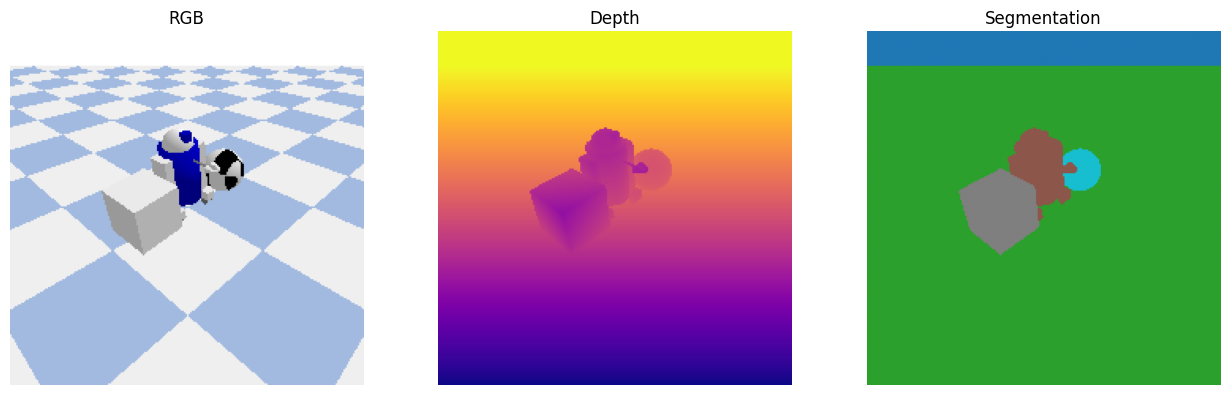

In [4]:

WIDTH, HEIGHT = 224, 224


p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.8)

p.loadURDF("plane.urdf")
p.loadURDF("r2d2.urdf",    basePosition=[ 0.0,  0.0, 1.0])
p.loadURDF("cube.urdf",    basePosition=[ 0.5,  0.0, 0.5], globalScaling=0.5)
p.loadURDF("sphere2.urdf", basePosition=[-0.5,  0.0, 0.5], globalScaling=0.5)

for _ in range(100):
    p.stepSimulation()


view_matrix = p.computeViewMatrix(
    cameraEyePosition=[2, 2, 2],
    cameraTargetPosition=[0, 0, 0],
    cameraUpVector=[0, 0, 1],
)
proj_matrix = p.computeProjectionMatrixFOV(
    fov=60, aspect=1.0, nearVal=0.1, farVal=10.0
)


_, _, rgb_raw, depth_raw, seg_raw = p.getCameraImage(
    width=WIDTH, height=HEIGHT,
    viewMatrix=view_matrix,
    projectionMatrix=proj_matrix,
    renderer=p.ER_TINY_RENDERER,
)
p.disconnect()

rgb   = np.array(rgb_raw,   dtype=np.uint8  )[:, :, :3]   # (H, W, 3)
depth = np.array(depth_raw, dtype=np.float32)              # (H, W)
seg   = np.array(seg_raw,   dtype=np.int32  )              # (H, W)

print(" Step 1 done")
print(f"  RGB   : {rgb.shape}")
print(f"  Depth : {depth.shape},  range [{depth.min():.3f}, {depth.max():.3f}]")
print(f"  Seg   : {seg.shape},    unique IDs {np.unique(seg).tolist()}")
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(rgb);                      axes[0].set_title("RGB");          axes[0].axis("off")
axes[1].imshow(depth, cmap="plasma");     axes[1].set_title("Depth");        axes[1].axis("off")
axes[2].imshow(seg,   cmap="tab10");      axes[2].set_title("Segmentation"); axes[2].axis("off")
plt.tight_layout()
plt.show()


---
## Step 2 Bounding Boxes from Segmentation Mask
PyBullet's segmentation mask tells us *exactly* which pixels belong to each object
i convert that into axis-aligned bounding boxes **for free** — no detector needed

Each box stores `[x1_norm, y1_norm, x2_norm, y2_norm, mean_depth]` in `[0, 1]`.


 Step 2 done 3 object(s) detected
  Object 1: box=[89, 61, 132, 119], depth=0.9757
  Object 2: box=[58, 87, 108, 141], depth=0.9740
  Object 3: box=[124, 74, 147, 100], depth=0.9811


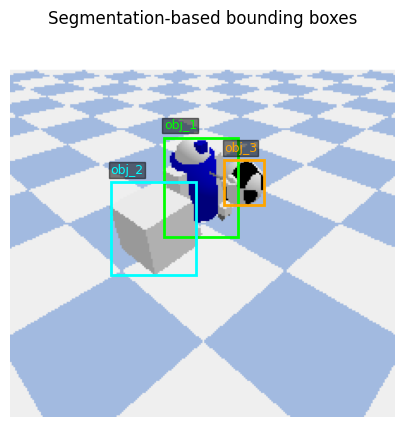

In [7]:

MAX_OBJECTS    = 5
FEATURES_PER_BOX = 5   # x1, y1, x2, y2, mean_depth  (all normalised)


def seg_to_boxes(seg_map, depth_map, min_pixels=50):
    """Return list of dicts {object_id, box:[x1,y1,x2,y2], mean_depth}."""
    H, W = seg_map.shape
    boxes = []
    for obj_id in np.unique(seg_map):
        if obj_id <= 0:         
            continue
        mask = (seg_map == obj_id)
        if mask.sum() < min_pixels:
            continue
        rows = np.where(mask.any(axis=1))[0]
        cols = np.where(mask.any(axis=0))[0]
        boxes.append({
            "object_id":  int(obj_id),
            "box":        [int(cols.min()), int(rows.min()),
                           int(cols.max()), int(rows.max())],
            "mean_depth": float(depth_map[mask].mean()),
        })
    return boxes


scene_boxes = seg_to_boxes(seg, depth)

print(f" Step 2 done {len(scene_boxes)} object(s) detected")
for b in scene_boxes:
    print(f"  Object {b['object_id']}: box={b['box']}, depth={b['mean_depth']:.4f}")

fig, ax = plt.subplots(1, figsize=(5, 5))
ax.imshow(rgb)
palette = ["lime", "cyan", "orange", "red", "magenta"]
for i, obj in enumerate(scene_boxes):
    x1, y1, x2, y2 = obj["box"]
    color = palette[i % len(palette)]
    ax.add_patch(patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor=color, facecolor="none",
    ))
    ax.text(x1, y1 - 5, f"obj_{obj['object_id']}",
            color=color, fontsize=9,
            bbox=dict(facecolor="black", alpha=0.5, pad=1))
ax.set_title("Segmentation-based bounding boxes")
ax.axis("off")
plt.show()


---
## Step 3 Visual Features via FPN Backbone
i run the **Faster R-CNN FPN backbone** (ImageNet-pretrained) in one forward pass
The `"0"` feature map from the FPN pyramid is global-average-pooled to a **(256,)** vector.

This is more efficient than the earlier approach (ResNet18 + separate Faster R-CNN detector)
because we use **one model, one pass** instead of two


In [8]:
#FPN backbone to visual feature vector

backbone = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
).backbone.to(DEVICE).eval()

_to_tensor = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),   
])

frame_t = _to_tensor(rgb).unsqueeze(0).to(DEVICE)   # (1, 3, H, W)

with torch.no_grad():
    feature_maps = backbone(frame_t)   # dict: "0","1","2","3","pool"


vis_feat = feature_maps["0"]                    # (1, 256, H', W')
vis_feat = vis_feat.mean(dim=[2, 3]).squeeze(0) # (256,)
vis_feat = F.normalize(vis_feat, dim=0)

print(" Step 3 done")
print(f"  Visual feature shape : {vis_feat.shape}")
print(f"  Min / Max / Mean     : {vis_feat.min().item():.4f} / "
      f"{vis_feat.max().item():.4f} / {vis_feat.mean().item():.4f}")


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 165MB/s]  


 Step 3 done
  Visual feature shape : torch.Size([256])
  Min / Max / Mean     : -0.1631 / 0.1565 / 0.0055


---
## Step 4 Detection Vector (Boxes + Depth)
Pack up to `MAX_OBJECTS=5` boxes into a fixed-size **(25,)** tensor.
Each slot = `[x1_norm, y1_norm, x2_norm, y2_norm, mean_depth]`.
Unused slots remain zero-padded.


In [10]:
# fixed-size detection vector 
def build_detection_vector(boxes, seg_map, depth_map,
                            max_objects=MAX_OBJECTS,
                            features_per_box=FEATURES_PER_BOX):
    H, W = seg_map.shape
    vec  = np.zeros(max_objects * features_per_box, dtype=np.float32)
    for i, obj in enumerate(boxes[:max_objects]):
        x1, y1, x2, y2 = obj["box"]
        idx = i * features_per_box
        vec[idx : idx + 5] = [x1/W, y1/H, x2/W, y2/H, obj["mean_depth"]]
    return vec


det_vec = build_detection_vector(scene_boxes, seg, depth)
det_t   = F.normalize(torch.tensor(det_vec).to(DEVICE), dim=0)

print(" Step 4 done")
print(f"  Detection vector shape : {det_t.shape}")


 Step 4 done
  Detection vector shape : torch.Size([25])


---
## Observation Tensor & Week 2 Check
concatenate visual features **(256,)** + detection vector **(25,)** → **(281,)**.

The dummy `Linear(281 → 7)` policy (7-DOF arm actions) must accept this without errors.


In [13]:

observation = torch.cat([vis_feat, det_t], dim=0)   # (281,)


print("M3 VISION WEEK 2 OBSERVATION TENSOR")

print(f"  Visual features   : {vis_feat.shape}")
print(f"  Detection vector  : {det_t.shape}")
print(f"  Observation tensor: {observation.shape}  ← hand to RL team")
print(f"  Min / Max / Mean  : {observation.min().item():.4f} / "
      f"{observation.max().item():.4f} / {observation.mean().item():.4f}")

#Dummy policy check 
OBS_DIM    = observation.shape[0]   # 281
ACTION_DIM = 7                      # 7-DOF arm

dummy_policy = nn.Sequential(
    nn.Linear(OBS_DIM, 256),
    nn.ReLU(),
    nn.Linear(256, ACTION_DIM),
).to(DEVICE)

with torch.no_grad():
    action = dummy_policy(observation.unsqueeze(0))   # (1, 7)

print()
print(" WEEK 2 CHECK PASSED")
print(f"  Observation to dummy policy to action  {observation.shape} to {action.shape}")
print()
print("All in time to see")
print(f"  Input          RGB frame         (224, 224, 3)")
print(f"  Free (PyBullet) Depth + Seg mask (224, 224) each")
print(f"  Step 2          Boxes + depth    (25,)")
print(f"  Step 3          FPN features     (256,)")
print(f"  Output          Observation      ({OBS_DIM},)")
print(f"  Dummy output    Joint actions    {action.shape}")


M3 VISION WEEK 2 OBSERVATION TENSOR
  Visual features   : torch.Size([256])
  Detection vector  : torch.Size([25])
  Observation tensor: torch.Size([281])  ← hand to RL team
  Min / Max / Mean  : -0.1631 / 0.4140 / 0.0177

 WEEK 2 CHECK PASSED
  Observation to dummy policy to action  torch.Size([281]) to torch.Size([1, 7])

All in time to see
  Input          RGB frame         (224, 224, 3)
  Free (PyBullet) Depth + Seg mask (224, 224) each
  Step 2          Boxes + depth    (25,)
  Step 3          FPN features     (256,)
  Output          Observation      (281,)
  Dummy output    Joint actions    torch.Size([1, 7])
